In [1]:
%pip install HiggsML==0.1.4
#penser à restart le kernel après avoir fait ça

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 7.2 MB/s eta 0:00:00


: 

In [2]:
!git clone https://github.com/ST4-BlackSwan/Higgs-TeamB.git

Cloning into 'Higgs-TeamB'...
remote: Enumerating objects: 345, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 345 (delta 68), reused 59 (delta 43), pack-reused 229 (from 1)
Receiving objects: 100% (345/345), 8.20 MiB | 22.17 MiB/s, done.
Resolving deltas: 100% (170/170), done.


: 

In [ ]:
!ls

Higgs-TeamB  sample_data


In [3]:
!pwd
%cd Higgs-TeamB/
!pwd
!git checkout team/NN/main

/content
/content/Higgs-TeamB
/content/Higgs-TeamB
Branch 'team/NN/main' set up to track remote branch 'team/NN/main' from 'origin'.
Switched to a new branch 'team/NN/main'


In [4]:
!git pull

Already up to date.


In [5]:
!ls NN

data.py  distribution.py  main.py  README.md  significance.py  weighted_roc.py


In [6]:
!git status

On branch team/NN/main
Your branch is up to date with 'origin/team/NN/main'.

nothing to commit, working tree clean


In [23]:
!python NN/main.py

In [24]:
from NN.data import load_and_clean_blackswan, prepare_datasets

print("1/2 - Téléchargement et nettoyage des données via data.py...")
features, target, weights = load_and_clean_blackswan()

print("\n2/2 - Découpage, standardisation (StandardScaler) et équilibrage des poids...")
X_train, X_test, y_train, y_test, w_train, w_test, scaler = prepare_datasets(features, target, weights)

print("\n✅ Traitement terminé avec succès !")
print(f"Dimensions Train : {X_train.shape} | Dimensions Test : {X_test.shape}")

1/2 - Téléchargement et nettoyage des données via data.py...

2/2 - Découpage, standardisation (StandardScaler) et équilibrage des poids...

✅ Traitement terminé avec succès !
Dimensions Train : (1050000, 6) | Dimensions Test : (350000, 6)


In [25]:
from NN.main import NeuralNetwork

print("Initialisation du modèle séquentiel Keras...")
nn = NeuralNetwork(X_train)

print("\nDémarrage de l'entraînement des époques (Optimiseur Adam)...")
nn.fit(X_train, y_train, weights_train=w_train)

print("\n✅ Réseau de neurones entraîné !")

Initialisation du modèle séquentiel Keras...

Démarrage de l'entraînement des époques (Optimiseur Adam)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
32813/32813 - 61s - 2ms/step - accuracy: 0.7503 - loss: 0.0812
Epoch 2/5
32813/32813 - 61s - 2ms/step - accuracy: 0.7527 - loss: 0.0803
Epoch 3/5
32813/32813 - 58s - 2ms/step - accuracy: 0.7542 - loss: 0.0799
Epoch 4/5
32813/32813 - 59s - 2ms/step - accuracy: 0.7557 - loss: 0.0795
Epoch 5/5
32813/32813 - 57s - 2ms/step - accuracy: 0.7563 - loss: 0.0793

✅ Réseau de neurones entraîné !


1/3 - Calcul des prédictions sur l'ensemble de test...
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step

2/3 - Génération des métriques et des graphiques physiques...
----------------------------------------
ROC EVALUATION COMPLETED
Weighted ROC AUC Score: 0.8139
----------------------------------------
Physics diagnostic: Score distribution overlay plot generated successfully.

3/3 - Calcul du seuil de sélection optimal...
SIGNIFICANCE OPTIMIZATION COMPLETE
Max Significance:   3.577 sigma
Optimal Score Cut:  0.78
Yields at Cut:      Signal=301.22, Background=6789.42

📊 TABLEAU DE BORD DES PERFORMANCES :


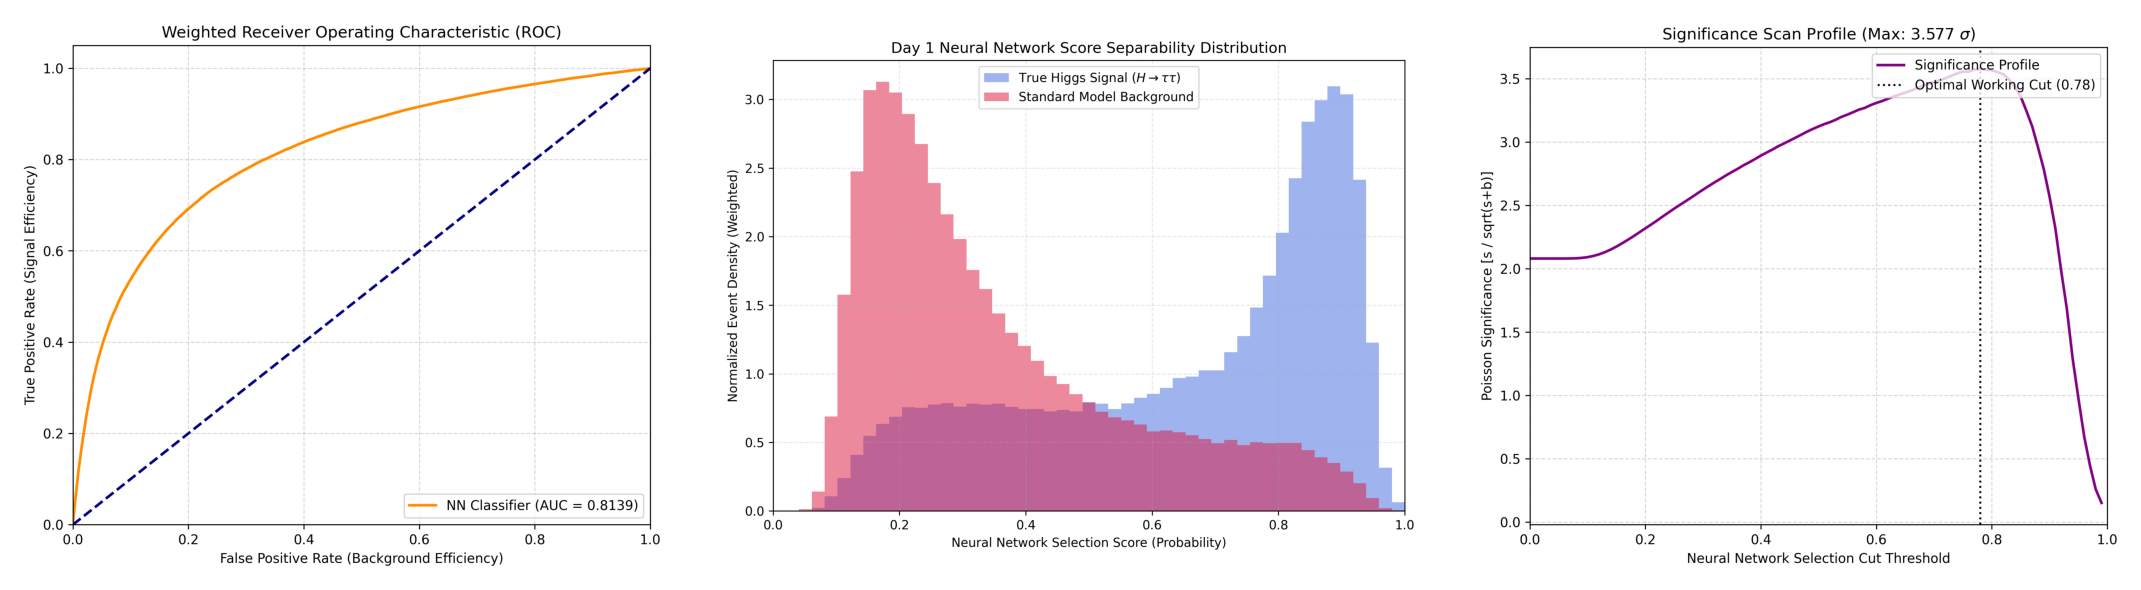

In [26]:
import cv2
import matplotlib.pyplot as plt
from NN.weighted_roc import calculate_weighted_roc
from NN.distribution import plot_score_separability
from NN.significance import optimize_poisson_significance

print("1/3 - Calcul des prédictions sur l'ensemble de test...")
predictions = nn.predict(X_test)

print("\n2/3 - Génération des métriques et des graphiques physiques...")
calculate_weighted_roc(y_test, predictions, sample_weights=w_test)
plot_score_separability(y_test, predictions, sample_weights=w_test)

print("\n3/3 - Calcul du seuil de sélection optimal...")
optimal_cut, max_sig = optimize_poisson_significance(y_test, predictions, sample_weights=w_test)

# --- Affichage des diagnostics générés ---
print("\n📊 TABLEAU DE BORD DES PERFORMANCES :")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

img_roc = cv2.imread("nn_day1_roc_curve.png")
axes[0].imshow(cv2.cvtColor(img_roc, cv2.COLOR_BGR2RGB))
axes[0].axis('off')

img_dist = cv2.imread("nn_day1_score_distribution.png")
axes[1].imshow(cv2.cvtColor(img_dist, cv2.COLOR_BGR2RGB))
axes[1].axis('off')

img_sig = cv2.imread("nn_day1_significance_scan.png")
axes[2].imshow(cv2.cvtColor(img_sig, cv2.COLOR_BGR2RGB))
axes[2].axis('off')

plt.tight_layout()
plt.show()